# TP 5 Text Mining:

In [26]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Charger le jeu de données Excel
Charger le jeu de données dans un dataFrame `pandas` et explorer les colonnes (on s'attend à avoir les colonnes `category` et `text`).

In [27]:
dataset_path = 'TP5 dataset Travail a faire Kmeans .xlsx'
df = pd.read_excel(dataset_path)

display(df.head())

print(df.info())

print("\nCategory Distribution:")
print(df['category'].value_counts())

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB
None

Category Distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


## 2. Vectorisation du texte

In [28]:
vectorizer = TfidfVectorizer(stop_words='english')

X_text = df['text'].fillna('')
X = vectorizer.fit_transform(X_text)

print(f"Shape of TF-IDF matrix: {X.shape}")

Shape of TF-IDF matrix: (2225, 29126)


## 3. Définition du nombre optimal de clusters K
Avant d'appliquer K-Means, nous devons évaluer pour différentes valeurs de `k` certaines métriques comme l'**Inertie (Méthode du coude)** et le **Score de Silhouette** pour trouver la valeur de $K$ la plus optimale.

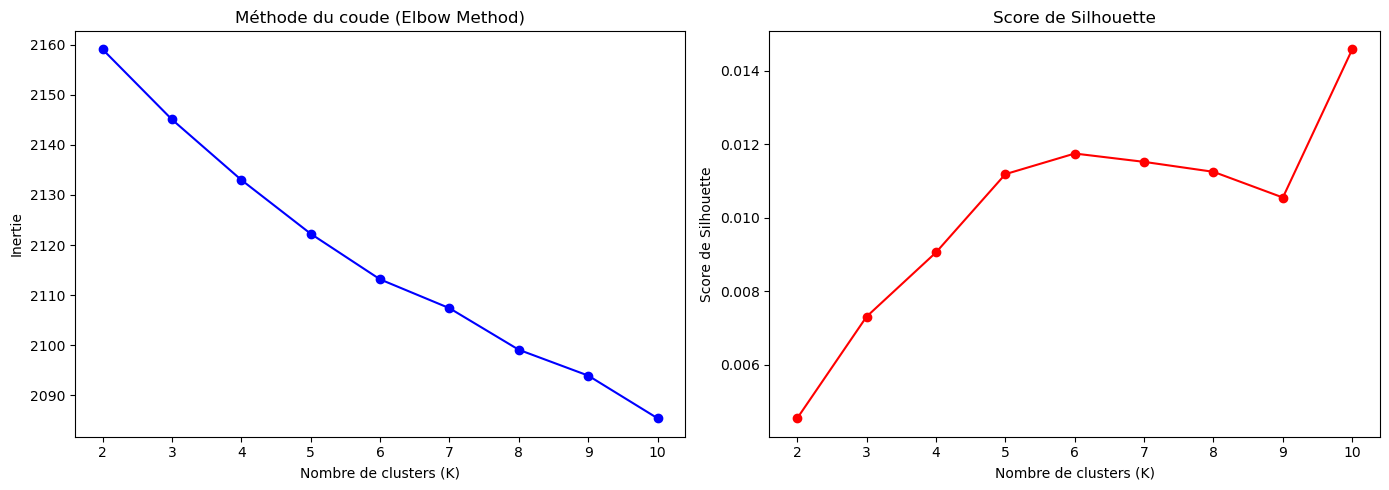

In [29]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k_val in K_range:
    kmeans_temp = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    kmeans_temp.fit(X)
    
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans_temp.labels_))

# Tracé de la méthode du coude
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', color='b')
plt.title('Méthode du coude (Elbow Method)')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie')

# Tracé du score de Silhouette
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='r')
plt.title('Score de Silhouette')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Score de Silhouette')

plt.tight_layout()
plt.show()

## 4. Application du clustering K-Means et Évaluation
Au lieu de fixer un seul K, nous allons tester différentes valeurs suspectées pour $K$ (par exemple, 5, 6 et 10). Pour chaque valeur, nous allons appliquer l'algorithme K-Means et évaluer la correspondance des clusters avec nos étiquettes réelles en utilisant l'indice de Rand Ajusté (Adjusted Rand Index — ARI) et en affichant une matrice de confusion (tableau croisé).

ÉVALUATION POUR K = 5
Adjusted Rand Index (ARI) : 0.6276



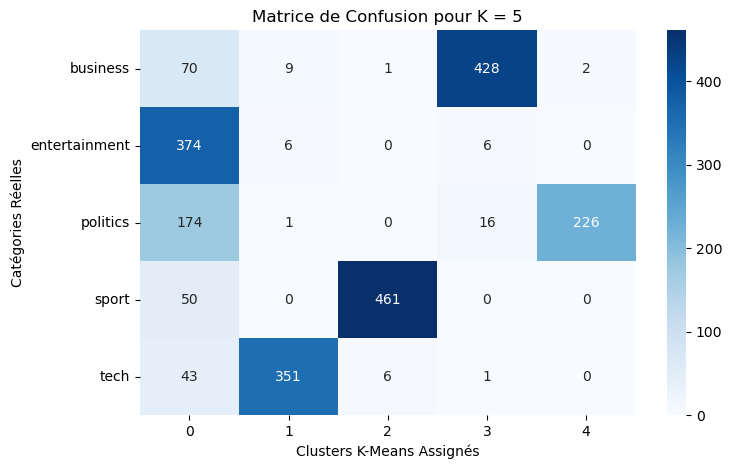




ÉVALUATION POUR K = 6
Adjusted Rand Index (ARI) : 0.7083



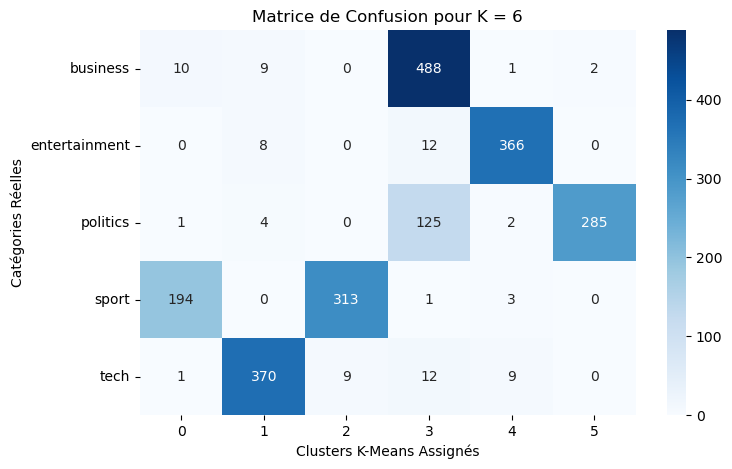




ÉVALUATION POUR K = 10
Adjusted Rand Index (ARI) : 0.3630



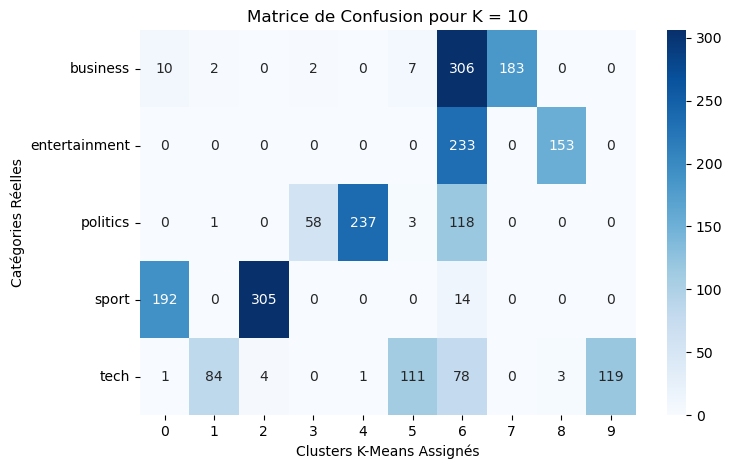

In [30]:
true_labels = df['category'].values
suspected_k_values = [5, 6, 10]

for k in suspected_k_values:
    print(f"{'='*60}")
    print(f"ÉVALUATION POUR K = {k}")
    print(f"{'='*60}")
    
    # 1. Initialiser et entraîner K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    
    # Assigner les étiquettes de cluster
    cluster_labels = kmeans.labels_
    
    # 2. Calculer le score Adjusted Rand Index (ARI)
    ari = adjusted_rand_score(true_labels, cluster_labels)
    print(f"Adjusted Rand Index (ARI) : {ari:.4f}\n")
    
    # 3. Créer et afficher le tableau croisé
    crosstab = pd.crosstab(df['category'], cluster_labels)
    # print("Tableau croisé des catégories réelles vs. Clusters assignés :")
    # display(crosstab)
    
    # 4. Visualisation avec Seaborn (Heatmap)
    plt.figure(figsize=(8, 5))
    sns.heatmap(crosstab, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Matrice de Confusion pour K = {k}")
    plt.ylabel("Catégories Réelles")
    plt.xlabel("Clusters K-Means Assignés")
    plt.show()
    plt.show()
    print("\n\n")

## Conclusion
Dans ce TP, nous avons appliqué l'algorithme de clustering **K-Means** sur un corpus textuel non étiqueté, après l'avoir transformé via la représentation **TF-IDF**. 

Grâce à la métrique de l'**Indice de Rand Ajusté (Adjusted Rand Index)** et à la matrice de confusion, nous avons pu évaluer dans quelle mesure les clusters formés non supervisés correspondent aux vraies catégories du jeu de données. Cela confirme que l'approche TF-IDF + K-Means est souvent un excellent point de départ pour grouper sémantiquement des documents textuels.